In [1]:
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay, f1_score
from sklearn.model_selection import cross_val_score, StratifiedKFold
import matplotlib.pyplot as plt
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin
import numpy as np
import pandas as pd
from sklearn.feature_selection import RFE
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier
from skopt import BayesSearchCV
from sklearn.model_selection import StratifiedKFold
from imblearn.pipeline import Pipeline as ImbPipeline
from skopt.space import Real, Integer
import mlflow
from sklearn.model_selection import GridSearchCV

# useful methods

below are some useful methods that I am going to be using later on.


## constant remover

simply removes columns that only have 1 unique value

In [2]:

# === 1. Drop constant columns ===
class ConstantColumnRemover(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.cols_to_keep = [col for col in X.columns if X[col].nunique() > 1]
        # mlflow.log_param("ConstantColumnRemover_cols_kept", len(self.cols_to_keep))
        return self
    def transform(self, X):
        return X[self.cols_to_keep]
    

## NA filler(cleaning)

fill nan/null values of the dataframe. the user can specify how it wants categorical and numerical columns to be handled. by default, categorical values become "missing" and numericals become 999.

In [3]:
# === 2. NAFiller ===
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.impute import SimpleImputer

class NAFiller(BaseEstimator, TransformerMixin):
    def __init__(self, num_strategy='mean', num_fill_value=999,
                 cat_strategy='constant', cat_fill_value='Missing'):
        self.num_strategy = num_strategy
        self.num_fill_value = num_fill_value
        self.cat_strategy = cat_strategy
        self.cat_fill_value = cat_fill_value

    def fit(self, X, y=None):
        self.num_cols = X.select_dtypes(include=['number']).columns.tolist()
        self.cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

        self.num_imputer = SimpleImputer(strategy=self.num_strategy, fill_value=self.num_fill_value)
        if self.num_cols:
            self.num_imputer.fit(X[self.num_cols])

        self.cat_imputer = SimpleImputer(strategy=self.cat_strategy, fill_value=self.cat_fill_value)
        if self.cat_cols:
            self.cat_imputer.fit(X[self.cat_cols])

        return self

    def transform(self, X):
        X = X.copy()
        if self.num_cols:
            X[self.num_cols] = self.num_imputer.transform(X[self.num_cols])
        if self.cat_cols:
            X[self.cat_cols] = self.cat_imputer.transform(X[self.cat_cols])
        return X
    

## NAFillerSearch(cleaning)

a better version of the method described above. used for optimising, i can choose 4 different fill methods with the number 0,1,2,3. 0 is fill with 0, 1 is fil with 99, 2 is fill with mean and 3 is fill with most common.

In [4]:
class NAFillerSearch(BaseEstimator, TransformerMixin):
    def __init__(self, strategy=0, cat_strategy='constant', cat_fill_value='Missing'):
        self.strategy = strategy
        self.cat_strategy = cat_strategy
        self.cat_fill_value = cat_fill_value

    def fit(self, X, y=None):
        if self.strategy == 1:
            num_strategy = 'constant'
            num_fill_value = 99
        elif self.strategy == 2:
            num_strategy = 'mean'
            num_fill_value = 0
        elif self.strategy == 3:
            num_strategy = 'most_frequent'
            num_fill_value = 0
        else:
            num_strategy = 'constant'
            num_fill_value = 0

        # mlflow.log_param("NAFillerSearch_num_strategy", num_strategy)
        # mlflow.log_param("NAFillerSearch_cat_strategy", self.cat_strategy)

        self.num_cols = X.select_dtypes(include=['number']).columns.tolist()
        self.cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

        self.num_imputer = SimpleImputer(strategy=num_strategy, fill_value=num_fill_value)
        if self.num_cols:
            self.num_imputer.fit(X[self.num_cols])

        self.cat_imputer = SimpleImputer(strategy=self.cat_strategy, fill_value=self.cat_fill_value)
        if self.cat_cols:
            self.cat_imputer.fit(X[self.cat_cols])

        return self

    def transform(self, X):
        X = X.copy()
        if self.num_cols:
            X[self.num_cols] = self.num_imputer.transform(X[self.num_cols])
        if self.cat_cols:
            X[self.cat_cols] = self.cat_imputer.transform(X[self.cat_cols])
        return X

## encoder(cleaning)

this method turns categorical columns into numerical. it takes a threshold, below is OHE and above - WOE. can be used with bayesian search to find the optimal value of the threshold.

In [5]:

# === 3. Encoder ===

class Encoder(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=3):
        self.threshold = threshold
        self.ohe_cols = []
        self.woe_cols = []
        self.woe_maps = {}
        self.ohe_df_columns = []

    def fit(self, X, y):
        # mlflow.log_param("Encoder_threshold", self.threshold)
        X = X.copy()
        y = pd.Series(y).reset_index(drop=True)
        
        for col in X.select_dtypes(include=['object', 'category']):
            unique_vals = X[col].nunique(dropna=True)
            if unique_vals < self.threshold:
                self.ohe_cols.append(col)
            else:
                self.woe_cols.append(col)
                self.woe_maps[col] = self._compute_woe(X[col], y)

        if self.ohe_cols:
            ohe_df = pd.get_dummies(X[self.ohe_cols], dummy_na=True)
            self.ohe_df_columns = ohe_df.columns.tolist()
        # print("finished fitting Encoder")
        # mlflow.log_param("Encoder_ohe_cols", len(self.ohe_cols))
        # mlflow.log_param("Encoder_woe_cols", len(self.woe_cols))
        
        return self

    def transform(self, X):
        X = X.copy()
        output = X.drop(columns=self.ohe_cols + self.woe_cols, errors='ignore')

        # Apply WOE encoding
        for col in self.woe_cols:
            woe_map = self.woe_maps[col]
            X[col] = X[col].map(woe_map).fillna(0)  # fill unknown categories with 0
            output[col] = X[col]

        # Apply One-Hot Encoding
        if self.ohe_cols:
            ohe_df = pd.get_dummies(X[self.ohe_cols], dummy_na=True)
            # Align with training columns to ensure consistency
            ohe_df = ohe_df.reindex(columns=self.ohe_df_columns, fill_value=0)
            output = pd.concat([output, ohe_df], axis=1)
        # print("finished transforming Encoder")
        return output

    def _compute_woe(self, feature_col, target_col):
        df = pd.DataFrame({'feature': feature_col, 'target': target_col})
        df = df.dropna(subset=['feature'])  # Drop missing for WOE mapping
        grouped = df.groupby('feature')

        # total good and bad
        total_good = (df['target'] == 0).sum()
        total_bad = (df['target'] == 1).sum()

        woe_map = {}
        for val, group in grouped:
            good = (group['target'] == 0).sum()
            bad = (group['target'] == 1).sum()

            # Avoid division by zero
            epsilon = 1e-6
            good_ratio = good / total_good if total_good else epsilon
            bad_ratio = bad / total_bad if total_bad else epsilon
            woe = np.log((good_ratio + epsilon) / (bad_ratio + epsilon))

            woe_map[val] = woe

        return woe_map



## simple feature engineering

this class makes new columns based on old ones. In this kaggle task it is very difficult to do so, as the columns are hidden and unintuitive, but there are some manipulations we could do, such as dividing the date into weeks and months. I also wanted to create columns such as the average transaction per user, but refrained from doing so as i believed I did not have enough data to do so, but it is a possibility.

In [ ]:

# === 4. Feature Engineering ===
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def __init__(self, origin_date=pd.Timestamp('2017-11-30')):
        self.origin_date = origin_date

    def fit(self, X, y=None):
        # print("finished fitting FeatureEngineer")
        return self

    def transform(self, X):
        X = X.copy()
        if 'TransactionDT' in X.columns:
            X['datetime'] = self.origin_date + pd.to_timedelta(X['TransactionDT'], unit='s')
            X['weekday'] = X['datetime'].dt.weekday
            X['month'] = X['datetime'].dt.month
            X.drop(columns=['datetime'], inplace=True)

        if 'TransactionAmt' in X.columns and 'card1' in X.columns:
            X['card1_avg_amt'] = X.groupby('card1')['TransactionAmt'].transform('mean')
        # print('finished transforming FeatureEngineer')
        return X

#  RFE,  correlationFilter (feature selection)

I am using those two to select my features. i did not make a custom RFE class of course). everythin is neatly packaged in my pipeline.

In [6]:

# === 5. Correlation Filter ===
class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.8):
        self.threshold = threshold
        self.cols_to_keep = []

    def fit(self, X, y=None):
        X = X.copy()
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

        cols_to_drop = set()
        for col in upper.columns:
            high_corr = upper[col][upper[col] > self.threshold]
            for row_col in high_corr.index:
                if row_col in cols_to_drop or col in cols_to_drop:
                    continue
                if y is not None:
                    col_corr = abs(np.corrcoef(X[col], y)[0, 1])
                    row_col_corr = abs(np.corrcoef(X[row_col], y)[0, 1])
                    drop_col = col if col_corr < row_col_corr else row_col
                else:
                    drop_col = row_col  # fallback
                cols_to_drop.add(drop_col)
        
        self.cols_to_keep = [col for col in X.columns if col not in cols_to_drop]
        # mlflow.log_param("correlation_amount_cols_dropped", len(cols_to_drop))
        # mlflow.log_param("correlation_amount_cols_kept", len(self.cols_to_keep))

        return self

    def transform(self, X):
        return X[self.cols_to_keep]

## scalers

just scalers. the reason i made it separately is that mine ignores NAN values. when I inputted 9999 into the NAfiller, it the total number used to calculate mean and deviation got too big and it would give me errors, therefore i thought about reducing everything first and then using 99.

In [7]:

# === 6. scaler ===

class Scaler(BaseEstimator, TransformerMixin):
    def __init__(self, scaler=None):
        self.scaler = scaler if scaler is not None else StandardScaler()
        self.columns = []

    def fit(self, X, y=None):
        X = X.copy()
        self.columns = X.select_dtypes(include=[np.number]).columns.tolist()
        self.scaler.fit(X[self.columns])
        # print("finished fitting Scaler")
        return self

    def transform(self, X):
        X = X.copy()
        X[self.columns] = self.scaler.transform(X[self.columns])
        # print("finished transforming Scaler")
        return X




class GaussianNormalizer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.means_ = {}
        self.stds_ = {}
        self.columns = []

    def fit(self, X, y=None):
        X = X.copy()
        self.columns = X.select_dtypes(include=[np.number]).columns.tolist()
        for col in self.columns:
            col_data = X[col].dropna()
            self.means_[col] = col_data.mean()
            self.stds_[col] = col_data.std(ddof=0)  # population std
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.columns:
            mean = self.means_[col]
            std = self.stds_[col]
            if std == 0 or np.isnan(std):
                X[col] = 0  # handle constant or all-NaN columns
            else:
                X[col] = (X[col] - mean) / std
        return X


In [8]:
import pandas as pd
train_identity  = pd.read_csv('ieee-fraud-detection/train_identity.csv')
train_transaction  = pd.read_csv('ieee-fraud-detection/train_transaction.csv')
test_identity = pd.read_csv('ieee-fraud-detection/test_identity.csv')
test_transaction = pd.read_csv('ieee-fraud-detection/test_transaction.csv')
# Normalize column names (replace '-' with '_')
train_identity.columns = train_identity.columns.str.replace('-', '_')
test_identity.columns = test_identity.columns.str.replace('-', '_')
train = pd.merge(train_transaction, train_identity, on='TransactionID', how='left')
test = pd.merge(test_transaction, test_identity, on='TransactionID', how='left')

In [9]:
# Usage
X = train.drop(columns=['isFraud', 'TransactionID'], errors='ignore')
y = train['isFraud']
X_test = test.drop(columns=['TransactionID'], errors='ignore')

In [10]:
import dagshub
import mlflow
import mlflow.sklearn
# Initialize DagsHub logging
dagshub.init(repo_owner='arazm21', repo_name='ML-homework_2', mlflow=True)

Accessing as arazm21

Initialized MLflow to track repo "arazm21/ML-homework_2"

Repository arazm21/ML-homework_2 initialized!

In [11]:

def log_pipeline_components(pipeline, prefix=""):
    """
    Logs all self.<attributes> from each step in a fitted pipeline using MLflow.
    """
    for name, step in pipeline.named_steps.items():
        if hasattr(step, '__dict__'):
            params_to_log = {f"{prefix}{name}__{k}": v for k, v in step.__dict__.items() if not k.startswith('_')}
            mlflow.log_params(params_to_log)


In [ ]:
import os
import tempfile
import mlflow
import mlflow.sklearn
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

from imblearn.pipeline import Pipeline as ImbPipeline
from skopt import BayesSearchCV
from skopt.space import Real, Integer

# Define your transformers or import them
# NAFillerSearch, ConstantColumnRemover, FeatureEngineer, Encoder, GaussianNormalizer, CorrelationFilter

# Prepare your pipeline
pipeline = ImbPipeline([
    ('undersampler', RandomUnderSampler(sampling_strategy=0.3)),
    ('na_filler', NAFillerSearch(strategy=3)),
    ('remove_constants', ConstantColumnRemover()),
    ('feature_engineering', FeatureEngineer()),
    ('categorical_encoding', Encoder(threshold=5)),
    ('GaussianNormalizer2', GaussianNormalizer()),
    ('correlation_filter', CorrelationFilter(threshold=0.8)),
    ('rfe', RFE(estimator=RandomForestClassifier(),step=30)),
    ('classifier', RandomForestClassifier(n_jobs=-1, random_state=42))
])

# Define search space
search_spaces = {
    'rfe__n_features_to_select': Integer(30, 100),
    'undersampler__sampling_strategy': Real(0.05, 0.5, prior='uniform'),
    'classifier__n_estimators': Integer(100, 500),
    'classifier__max_depth': Integer(5, 30),
    'classifier__min_samples_split': Integer(2, 10),
    'classifier__min_samples_leaf': Integer(1, 10),
    'classifier__max_features': Real(0.1, 1.0, prior='uniform'),
}

# Prepare datasets
X_train, X_eval, y_train, y_eval = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# 1. Set experiment (different for each model type)
mlflow.set_experiment("RandomForest_Training")

# Disable autologging initially
mlflow.sklearn.autolog(disable=True)


# Start Model Training Run
with mlflow.start_run(run_name="RandomForest_ModelTraining") as training_run:
    mlflow.set_tag("stage", "model_training")

    search = BayesSearchCV(
        pipeline,
        search_spaces,
        n_iter=10,
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        n_jobs=-1,
        scoring='f1',
        verbose=2,
        random_state=42,
        n_points=2
    )
    search.fit(X_train, y_train)

C:\Users\alex\Documents\university_work\ML\ML-homework_2\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(


C:\Users\alex\AppData\Local\Temp\ipykernel_23924\464962822.py:45: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  ohe_df = pd.get_dummies(X[self.ohe_cols], dummy_na=True)
C:\Users\alex\AppData\Local\Temp\ipykernel_23924\464962822.py:45: FutureWarning: The behavior of Index.insert with object-dtype is deprecated, in a future version this will return an object-dtype Index instead of inferring a non-object dtype. To retain the old behavior, do `idx.insert(loc, item).infer_objects(copy=False)`
  ohe_df = pd.get_dummies(X[self.ohe_cols], dummy_na=True)


🏃 View run RandomForest_ModelTraining at: https://dagshub.com/arazm21/ML-homework_2.mlflow/#/experiments/2/runs/6473887a68a741bcbbd182349e17a604
🧪 View experiment at: https://dagshub.com/arazm21/ML-homework_2.mlflow/#/experiments/2
Test ROC AUC: 0.9221920920997793
Best parameters found:
 OrderedDict({'classifier__max_depth': 27, 'classifier__max_features': 0.9207359753561953, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 435, 'rfe__n_features_to_select': 73, 'undersampler__sampling_strategy': 0.061828889913933496})
🏃 View run RandomForest_TestEvaluation at: https://dagshub.com/arazm21/ML-homework_2.mlflow/#/experiments/2/runs/536836bd941849cead783fa5866e81fb
🧪 View experiment at: https://dagshub.com/arazm21/ML-homework_2.mlflow/#/experiments/2


Registered model 'BestRandomForestPipeline' already exists. Creating a new version of this model...
2025/05/01 10:10:44 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: BestRandomForestPipeline, version 2
Created version '2' of model 'BestRandomForestPipeline'.


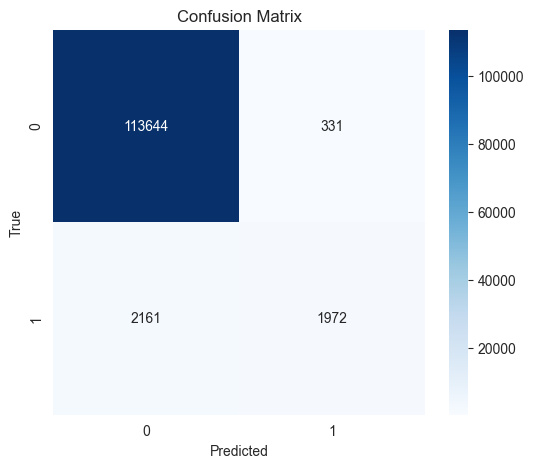

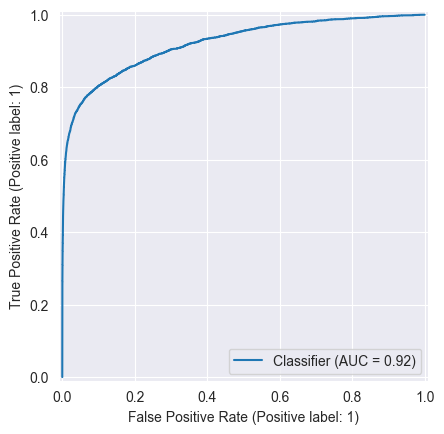

In [15]:
with mlflow.start_run(run_name="RandomForest_ModelTraining") as training_run:
    mlflow.log_params(search.best_params_)
    best_pipeline = search.best_estimator_
    log_pipeline_components(best_pipeline, prefix="rf_pipeline_")
    # Save best pipeline
    pipeline_model_path = "random_forest_pipeline"
    mlflow.sklearn.log_model(
        sk_model=search.best_estimator_,
        artifact_path=pipeline_model_path,
        input_example=X_train.iloc[:5],
        signature=mlflow.models.infer_signature(X_train, search.predict(X_train))
    )

# Start Test Evaluation Run
with mlflow.start_run(run_name="RandomForest_TestEvaluation") as eval_run:
    mlflow.set_tag("stage", "test_evaluation")

    y_pred = search.predict(X_eval)
    y_proba = search.predict_proba(X_eval)[:, 1]

    roc_auc = roc_auc_score(y_eval, y_proba)
    f1 = f1_score(y_eval, y_pred)

    mlflow.log_metric("test_roc_auc", roc_auc)
    mlflow.log_metric("test_f1", f1)

    report = classification_report(y_eval, y_pred, output_dict=True)
    for label, scores in report.items():
        if isinstance(scores, dict):
            for metric, value in scores.items():
                mlflow.log_metric(f"{label}_{metric}", value)

    cm = confusion_matrix(y_eval, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    cm_path = os.path.join(tempfile.gettempdir(), "confusion_matrix.png")
    plt.savefig(cm_path)
    mlflow.log_artifact(cm_path)

    RocCurveDisplay.from_predictions(y_eval, y_proba)
    roc_path = os.path.join(tempfile.gettempdir(), "roc_curve.png")
    plt.savefig(roc_path)
    mlflow.log_artifact(roc_path)

    print("Test ROC AUC:", roc_auc)
    print("Best parameters found:\n", search.best_params_)

# Optionally: Model Registry Registration
model_name = "BestRandomForestPipeline"
model_uri = f"runs:/{training_run.info.run_id}/{pipeline_model_path}"

mlflow.register_model(model_uri=model_uri, name=model_name)

# Re-enable autologging if needed
mlflow.sklearn.autolog(disable=False)
